In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
import json
import warnings

In [1]:
from datasets import load_dataset

# 1. corpus.jsonl (검색 대상 문서들)
corpus_dataset = load_dataset("mteb/Ko-StrategyQA", "corpus", split="dev")
print("corpus features:", corpus_dataset.features)
print("corpus num_rows:", corpus_dataset.num_rows)
print("corpus sample[0]:", corpus_dataset[0])

# 2. queries.jsonl (검색 쿼리들)
queries_dataset = load_dataset("mteb/Ko-StrategyQA", "queries", split="dev")
print("\nqueries features:", queries_dataset.features)
print("queries num_rows:", queries_dataset.num_rows)
print("queries sample[0]:", queries_dataset[0])

# 3. qrels/ (쿼리–문서 관련성 레이블, dev split 기준)
qrels_dataset = load_dataset("mteb/Ko-StrategyQA", "qrels", split="dev")
print("\nqrels features:", qrels_dataset.features)
print("qrels num_rows:", qrels_dataset.num_rows)
print("qrels sample[0]:", qrels_dataset[0])

README.md: 0.00B [00:00, ?B/s]

corpus/dev-00000-of-00001.parquet:   0%|          | 0.00/4.43M [00:00<?, ?B/s]

Generating dev split:   0%|          | 0/9251 [00:00<?, ? examples/s]

corpus features: {'_id': Value('string'), 'text': Value('string'), 'title': Value('string')}
corpus num_rows: 9251
corpus sample[0]: {'_id': '17th century-1', 'text': '17세기는 1601년 1월 1일부터 1700년 12월 31일까지 지속된 세기입니다. 이 시기는 유럽의 근대 초기에 속하며, 바로크 문화 운동, 스페인 황금 시대의 후반부, 네덜란드 황금 시대, 루이 14세가 지배한 프랑스 왕정 시대, 과학 혁명, 세계 최초의 공기업이자 거대 기업인 네덜란드 동인도 회사, 일부 역사가에 따르면 일반 위기 등이 특징적인 시기였다. 가장 큰 군사적 분쟁은 30년 전쟁, 터키 대전쟁, 무굴-사파비 전쟁(무굴-사파비 전쟁(1622-23), 무굴-사파비 전쟁(1649-53)), 무굴-마라타 전쟁, 네덜란드-포르투갈 전쟁 등이었습니다. 또한 이 시기에는 은 매장지 개발 등 유럽의 아메리카 식민지 개척이 본격적으로 시작되어 부의 유럽 유입으로 인플레이션이 발생하기도 했습니다.', 'title': '17th century'}


queries/dev-00000-of-00001.parquet:   0%|          | 0.00/31.6k [00:00<?, ?B/s]

Generating dev split:   0%|          | 0/592 [00:00<?, ? examples/s]


queries features: {'_id': Value('string'), 'text': Value('string')}
queries num_rows: 592
queries sample[0]: {'_id': '5c27625de0e7c35be856_0', 'text': '토니 베넷의 중간 이름은 무엇인가요?'}


qrels/dev-00000-of-00001.parquet:   0%|          | 0.00/27.6k [00:00<?, ?B/s]

Generating dev split:   0%|          | 0/1145 [00:00<?, ? examples/s]


qrels features: {'query-id': Value('string'), 'corpus-id': Value('string'), 'score': Value('int64')}
qrels num_rows: 1145
qrels sample[0]: {'query-id': '5c27625de0e7c35be856_0', 'corpus-id': 'Tony Bennett-1', 'score': 1}


In [3]:
from datasets import load_dataset

# 1. 데이터 로드
corpus_dataset = load_dataset("mteb/Ko-StrategyQA", "corpus", split="dev")
queries_dataset = load_dataset("mteb/Ko-StrategyQA", "queries", split="dev")
qrels_dataset   = load_dataset("mteb/Ko-StrategyQA", "qrels", split="dev")

# 2. corpus: doc_id → text 매핑 (딕셔너리)
corpus = {
    doc["_id"]: f"{doc['title']} {doc['text']}".strip()
    for doc in corpus_dataset
}

# 3. corpus_list, doc_id_list (임베딩/순서 유지용)
doc_id_list = list(corpus.keys())
corpus_list = [corpus[doc_id] for doc_id in doc_id_list]

# 4. queries: query_id → query text 매핑
queries = {item["_id"]: item["text"] for item in queries_dataset}

# 5. qrels: query_id → relevant doc_ids (set으로 저장)
qrels = {}
for row in qrels_dataset:
    qid = row["query-id"]
    did = row["corpus-id"]
    if qid not in qrels:
        qrels[qid] = set()
    qrels[qid].add(did)

# 확인 예시
print("corpus (# docs):", len(corpus))
print("queries (# queries):", len(queries))
print("qrels (# queries with rel docs):", len(qrels))
if qrels:
    example_qid = next(iter(qrels))
    print("example qrels:", example_qid, "->", list(qrels[example_qid])[:5])

corpus (# docs): 9251
queries (# queries): 592
qrels (# queries with rel docs): 592
example qrels: 5c27625de0e7c35be856_0 -> ['Tony Bennett-1']


In [2]:
!python -m pip install kiwipiepy

  Using cached kiwipiepy-0.23.1-cp39-abi3-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (1.3 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 11.2 MB/s  0:00:07m0:00:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 8.2 MB/s  0:00:006m0:00:0100:01
  Created wheel for kiwipiepy_model: filename=kiwipiepy_model-0.23.0-py3-none-any.whl size=88067872 sha256=74d88ee131fd426deb08afaddd1a5d7e92c8371eb6a5244842c04eff582c7028
  Stored in directory: /root/.cache/pip/wheels/f2/94/da/ff88b4c2305cd1f3effc8001b5f42f16dc9931bcd84d1e77c3
Successfully built kiwipiepy_model
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [kiwipiepy]model]


In [3]:
from kiwipiepy import Kiwi
import re

# Kiwi 인스턴스
kiwi = Kiwi()

# 불용어 예시 (필요하면 Ko-StrategyQA/도메인에 맞게 수정)
stopwords = set([
    "하다", "있다", "이다", "된다", "싶다", "같다", "보다", "때문에", "때문",
    "수", "등", "중", "이상", "이하", "이내",
    # 일반적인 조사/지나치게 흔한 단어
    "를", "이", "가", "에", "을", "의", "은", "는", "도", "으로", "으로써",
    "으며", "면서", "하지만", "그러나", "그리고", "또한", "또",
])

def tokenize_kiwi(text: str) -> list[str]:
    """
    kiwipiepy로 형태소 분석 후 다음 조건을 만족하는 토큰을 반환
    - 명사(NN*), 동사(VV), 형용사(VA)만 추출
    - 불용어 제거
    - 토큰 길이가 1 이하인 토큰 제거
    """
    tokens = kiwi.tokenize(text)

    result = []
    for token in tokens:
        surface = token.form
        pos_tag = token.tag

        # 1. 품사 필터: 명사(NN*), 동사(VV), 형용사(VA)
        # kiwipiepy 기준: NNG, NNP, NNB, NR, NP 등은 모두 체언(N) → 모두 NN*로 처리
        if pos_tag.startswith("N") or pos_tag in ("VV", "VA"):
            # 2. 불용어 제거
            if surface in stopwords:
                continue
            # 3. 길이 1 이하 제거
            if len(surface) <= 1:
                continue
            result.append(surface)

    return result

# 사용 예시
example_text = "이전 데이터셋으로부터 kiwipiepy 형태소 분석기를 사용하여 문장을 토큰화하는 함수가 필요합니다."
print("Original:", example_text)
print("Tokens:", tokenize_kiwi(example_text))

Original: 이전 데이터셋으로부터 kiwipiepy 형태소 분석기를 사용하여 문장을 토큰화하는 함수가 필요합니다.
Tokens: ['이전', '데이터', '형태소', '분석기', '사용', '문장', '토큰', '함수', '필요']


In [5]:
from datasets import load_dataset

# 1. Ko-StrategyQA corpus 로드
corpus_dataset = load_dataset("mteb/Ko-StrategyQA", "corpus", split="dev")

# 2. corpus_list 생성
corpus_list = [
    f"{doc['title']} {doc['text']}".strip()
    for doc in corpus_dataset
]

print("corpus_list 개수:", len(corpus_list))
print("예시: corpus_list[0] =", corpus_list[0][:80], "...")

from kiwipiepy import Kiwi

# 앞에서 정리한 형태소 분석 함수 가정
def tokenize_kiwi(text: str) -> list[str]:
    tokens = kiwi.tokenize(text)
    result = []
    for token in tokens:
        surface = token.form
        pos_tag = token.tag
        if pos_tag.startswith("N") or pos_tag in ("VV", "VA"):
            if surface in stopwords:  # stopwords 정의 필요
                continue
            if len(surface) <= 1:
                continue
            result.append(surface)
    return result

# 1. 전체 코퍼스 토큰화
kiwi = Kiwi()

# 예: corpus_list = [doc_text_1, doc_text_2, ...]
corpus_tokenized = [
    tokenize_kiwi(doc_text) for doc_text in corpus_list
]

# 결과 확인
print("corpus_tokenized 개수:", len(corpus_tokenized))
print("첫 번째 문서 토큰:", corpus_tokenized[0][:20])  # 처음 20개만 출력

corpus_list 개수: 9251
예시: corpus_list[0] = 17th century 17세기는 1601년 1월 1일부터 1700년 12월 31일까지 지속된 세기입니다. 이 시기는 유럽의 근대 초기에 속하며 ...
corpus_tokenized 개수: 9251
첫 번째 문서 토큰: ['세기', '지속', '세기', '시기', '유럽', '근대', '초기', '속하', '바로크', '문화', '운동', '스페인', '황금', '시대', '후반부', '네덜란드', '황금', '시대', '루이', '지배']


In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer_raw = TfidfVectorizer(
    lowercase=False,
    # token_pattern 생략 (기본값으로 띄어쓰기 기준 단어 토큰화)
)

tfidf_matrix_raw = tfidf_vectorizer_raw.fit_transform(corpus_list)

print("tfidf_matrix_raw shape:", tfidf_matrix_raw.shape)
print("feature names (예시, 처음 10개):", tfidf_vectorizer_raw.get_feature_names_out()[:10])

# 1. 토큰 리스트를 공백으로 이은 문자열 리스트로 변환
corpus_tokenized_joined = [" ".join(tok_list) for tok_list in corpus_tokenized]

# 2. TfidfVectorizer: analyzer만 word로 두고, token_pattern은 touch하지 말 것
tfidf_vectorizer = TfidfVectorizer(
    lowercase=False,
    analyzer="word",
    # token_pattern=None 하지 말기 (생략하거나 문자열로 줄 것)
)

tfidf_matrix = tfidf_vectorizer.fit_transform(corpus_tokenized_joined)
print("tfidf_matrix shape:", tfidf_matrix.shape)
print("feature names (예시, 처음 10개):", tfidf_vectorizer.get_feature_names_out()[:10])

tfidf_matrix_raw shape: (9251, 150836)
feature names (예시, 처음 10개): ['00' '000' '000000001m' '000039인치' '00015' '00067' '000Hz' '000Hz의'
 '000K' '000K에']
tfidf_matrix shape: (9251, 35399)
feature names (예시, 처음 10개): ['00' '101번' '10대' '12바' '13세' '13층' '1구' '1루' '1루수' '1세']


In [27]:
from datasets import load_dataset

corpus_dataset = load_dataset("mteb/Ko-StrategyQA", "corpus", split="dev")

corpus = {
    doc["_id"]: f"{doc['title']} {doc['text']}".strip()
    for doc in corpus_dataset
}

# doc_id_list 정의
doc_id_list = list(corpus.keys())

print(type(doc_id_list))  # <class 'list'>
print(len(doc_id_list))   # 수십~수백 개 문서가 나와야 함

from sklearn.metrics.pairwise import cosine_similarity

def search_tfidf(
    query,                    # 기본값 없음
    top_k=10,                 # 기본값 있음
    use_preprocessing=True,   # 기본값 있음
    doc_id_list=doc_id_list,
    tfidf_vectorizer_raw=tfidf_vectorizer_raw,
    tfidf_vectorizer=tfidf_vectorizer,
    tfidf_matrix_raw=tfidf_matrix_raw,
    tfidf_matrix=tfidf_matrix,
    tokenize_kiwi=tokenize_kiwi,
):
    """
    TF-IDF 기반 검색 함수
    """
    # 1. 어떤 벡터라이저/매트릭스를 쓸지 선택
    if use_preprocessing:
        # kiwi 토큰화 후 TF-IDF
        if tokenize_kiwi is None:
            raise ValueError("use_preprocessing=True이면 tokenize_kiwi 함수가 필요합니다.")
        # 쿼리 토큰화 후 공백으로 이음
        query_tokens = tokenize_kiwi(query)
        query_text = " ".join(query_tokens)
        vectorizer = tfidf_vectorizer
        matrix = tfidf_matrix
    else:
        # raw 텍스트 TF-IDF
        query_text = query
        vectorizer = tfidf_vectorizer_raw
        matrix = tfidf_matrix_raw

    # 2. 쿼리를 TF-IDF 벡터로 변환
    # (1, n_features) 형태로 나와야 함
    query_vec = vectorizer.transform([query_text])

    # 3. 코사인 유사도 계산
    # shape: (1, n_docs) → 1차원으로 flatten
    similarities = cosine_similarity(query_vec, matrix).flatten()

    # 4. 상위 top_k 문서 인덱스 가져오기
    top_indices = similarities.argsort()[::-1][:top_k]

    # 5. (doc_id, score) 리스트 반환
    results = [
        (doc_id_list[idx], similarities[idx]) for idx in top_indices
    ]

    return results

# 사용 예시
results = search_tfidf(
    query="Ko-StrategyQA 데이터셋을 로드해야 합니다.",
    top_k=10,
    use_preprocessing=True,
    doc_id_list=doc_id_list,
    tfidf_vectorizer_raw=tfidf_vectorizer_raw,
    tfidf_vectorizer=tfidf_vectorizer,
    tfidf_matrix_raw=tfidf_matrix_raw,
    tfidf_matrix=tfidf_matrix,
    tokenize_kiwi=tokenize_kiwi,
)
for doc_id, score in results:
    print(f"{doc_id} | {score:.4f}")

<class 'list'>
9251
CD-ROM-21 | 0.3783
Microsoft Excel-25 | 0.3654
Rhode Island-29 | 0.3603
International Tree-Ring Data Bank-1 | 0.3384
Hubble Space Telescope-84 | 0.2680
Spreadsheet-1 | 0.2371
New England-1 | 0.2241
Personal computer-10 | 0.2118
Smartphone-16 | 0.2092
Bluetooth-1 | 0.1934


In [18]:
from sentence_transformers import SentenceTransformer

# 1. 한국어 전용 SentenceBERT 모델 로드
model_name = "snunlp/KR-SBERT-V40K-klueNLI-augSTS"
model = SentenceTransformer(model_name)

print("Model:", model_name)
print("Embedding dim:", model.get_sentence_embedding_dimension())  # 768

# 2. 코퍼스 문장 리스트 (문장/문단 단위 문자열 리스트)
sentences = corpus_list  # ["문서1 텍스트", "문서2 텍스트", ...]

# 3. SentenceBERT로 전체 코퍼스 임베딩
import torch

with torch.no_grad():
    corpus_embeddings = model.encode(
        sentences,
        batch_size=32,              # GPU 메모리에 맞게 조정
        convert_to_numpy=True,      # numpy.ndarray로 반환
        show_progress_bar=True,
    )

print("corpus_embeddings shape:", corpus_embeddings.shape)  # (n_docs, 768)

# 4. doc_id 리스트와 임베딩을 함께 묶어두기
import numpy as np

doc_id_to_embedding = dict(zip(doc_id_list, corpus_embeddings))

# 예시
example_id = doc_id_list[0]
example_emb = doc_id_to_embedding[example_id]
print("example embedding shape:", example_emb.shape)  # (768,)



/root/lanMar/lib/python3.12/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model: snunlp/KR-SBERT-V40K-klueNLI-augSTS
Embedding dim: 768


/tmp/ipykernel_2906/572288113.py:8: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print("Embedding dim:", model.get_sentence_embedding_dimension())  # 768


Batches:   0%|          | 0/290 [00:00<?, ?it/s]

corpus_embeddings shape: (9251, 768)
example embedding shape: (768,)


In [20]:
from sentence_transformers import SentenceTransformer, util
import torch

def search_sbert(
    query: str,
    doc_id_list: list[str],
    model: SentenceTransformer,
    corpus_embeddings: torch.Tensor,  # 또는 numpy.ndarray → torch.Tensor로 변환
    top_k: int = 10,
):
    """
    SentenceBERT 기반 검색 함수
    - query: 검색 쿼리
    - doc_id_list: 문서 ID 리스트
    - model: SentenceTransformer 모델 (snunlp/KR-SBERT-... 등)
    - corpus_embeddings: 이미 계산된 코퍼스 임베딩 (shape: [n_docs, 768])
    - top_k: 상위 문서 개수 (기본 10)

    반환: [(doc_id, score), ...] 리스트
    """
    device = corpus_embeddings.device if isinstance(corpus_embeddings, torch.Tensor) else None

    # 1. 쿼리 임베딩
    # (n_query=1, 768) 형태로 반환
    query_embedding = model.encode(
        query,
        convert_to_tensor=True,
        device=device,
    )

    # 2. 코사인 유사도 계산 (query_embed × corpus_embeddings)
    # util.pytorch_cos_sim(a, b) 결과: [1, n_docs]
    cos_scores = util.pytorch_cos_sim(query_embedding, corpus_embeddings)[0]

    # 3. 상위 top_k 문서 인덱스/점수 추출
    # top_k 값을 실제 문서 수보다 크게 잡으면 에러 나므로 최소값 사용
    k = min(top_k, cos_scores.size(0))
    top_scores, top_indices = torch.topk(cos_scores, k=k, largest=True, sorted=True)

    # 4. (doc_id, score) 리스트 반환
    results = [
        (doc_id_list[idx.item()], score.item())
        for idx, score in zip(top_indices, top_scores)
    ]

    return results


"""
# 앞에서 정의한 것들 가정:
# model: SentenceTransformer("snunlp/KR-SBERT-V40K-klueNLI-augSTS")
# corpus_embeddings: torch.Tensor 또는 numpy.ndarray (문서 임베딩)
# doc_id_list: 문서 id 리스트
"""
results = search_sbert(
    query="Ko-StrategyQA 데이터셋을 로드해야 합니다.",
    doc_id_list=doc_id_list,
    model=model,
    corpus_embeddings=corpus_embeddings,
    top_k=10,
)

for doc_id, score in results:
    print(f"{doc_id:32} | {score:.4f}")

Starling Framework-2             | 0.5624
CAPTCHA-1                        | 0.5611
Official Scrabble Players Dictionary-9 | 0.5526
JPEG-2                           | 0.5384
Microsoft Excel-25               | 0.5346
Ray Tomlinson-5                  | 0.5180
UTC−08:00-1                      | 0.5178
QWERTY-9                         | 0.5139
Spreadsheet-1                    | 0.5051
Ubuntu-1                         | 0.5042


In [31]:
def show_comparison(
    query: str,
    query_id: str,   # Ko-StrategyQA에서 qid
    qrels: dict,     # query_id → set(doc_id)
    # TF-IDF 검색 함수
    search_tfidf_raw,          # raw TF-IDF
    search_tfidf_kiwi,         # kiwi 토큰 후 TF-IDF
    # SentenceBERT 검색 함수
    search_sbert,
    # 검색 함수에 필요한 인자
    **kwargs):
    # 1. 각 방식으로 검색
    # 1. 각 방식으로 검색
    raw_results = search_tfidf_raw(
        query, top_k=10, use_preprocessing=False, **kwargs
    )

    kiwi_results = search_tfidf_kiwi(
        query, top_k=10, use_preprocessing=True, **kwargs
    )

    sbert_results = search_sbert(
        query, **kwargs, top_k=10
    )
    # 2. 관련 문서 집합 가져오기 (없으면 빈 set)
    relevant_docs = qrels.get(query_id, set())

    # 3. 결과 출력
    print("=" * 100)
    print(f"QUERY [{query_id}]: {query}")
    print("Relevant docs:", " | ".join(relevant_docs))
    print("-" * 100)

    def format_rank_list(results: list[tuple[str, float]]) -> str:
        lines = []
        for i, (doc_id, score) in enumerate(results):
            mark = "✓" if doc_id in relevant_docs else " "
            lines.append(f"{i+1:2d} {mark} {doc_id:24} {score:7.4f}")
        return "\n".join(lines)

    print("❶ TF-IDF (전처리 없음)")
    print(format_rank_list(raw_results))
    print()

    print("❷ TF-IDF (Kiwi 토큰화)")
    print(format_rank_list(kiwi_results))
    print()

    print("❸ SentenceBERT (KR-SBERT)")
    print(format_rank_list(sbert_results))
    print("=" * 100)

In [19]:
def recall_at_k(
    top_k_docs: list[str],
    relevant_docs: set[str],
    k: int = None,
):
    """
    Recall@K = |relevant ∩ top-K| / |relevant|
    - top_k_docs: 상위 K 문서 ID 리스트
    - relevant_docs: 관련 문서 전체 집합
    - k: K 값 (넘기면 len(top_k_docs)를 그대로 사용)
    """
    if k is None:
        k = len(top_k_docs)
    # 상위 K 문서 중에서 relevant한 것
    top_k_set = set(top_k_docs[:k])
    intersection = top_k_set & relevant_docs
    recall = len(intersection) / len(relevant_docs) if relevant_docs else 0.0
    return recall
def mrr_at_k(
    top_k_docs: list[str],
    relevant_docs: set[str],
):
    """
    MRR은 한 쿼리당 1개만 쓰는 값 (RR = 1 / rank_i)
    여러 쿼리에 대해 MRR을 평균 내려면, 이 함수를 각 쿼리마다 호출 후 평균을 취하면 됨.
    - top_k_docs: 상위 문서 리스트
    - relevant_docs: 관련 문서 집합
    반환: RR (쿼리 하나에 대한 reciprocal rank)
    """
    for rank, doc_id in enumerate(top_k_docs, start=1):
        if doc_id in relevant_docs:
            return 1.0 / rank
    return 0.0  # 하나도 없으면 0
def evaluate_ranking(
    results: list[tuple[str, list[str], set[str]]],
    k: int = 10,
):
    """
    여러 쿼리에 대한 평균 Recall@K, MRR 계산

    results = [
        (query_id, top_k_docs, relevant_docs),  # 각 쿼리 1개
        ...
    ]

    반환: (avg_recall@k, avg_mrr@k, per_query_stats)
    """
    recalls = []
    rr_values = []

    per_query_stats = []

    for query_id, top_k_docs, relevant_docs in results:
        # Recall@K 계산
        recall = recall_at_k(top_k_docs, relevant_docs, k=k)

        # RR (각 쿼리의 1/rank_first)
        rr = mrr_at_k(top_k_docs, relevant_docs)

        recalls.append(recall)
        rr_values.append(rr)

        per_query_stats.append({
            "query_id": query_id,
            "recall@k": recall,
            "rr": rr,
        })

    avg_recall = sum(recalls) / len(recalls) if recalls else 0.0
    avg_mrr = sum(rr_values) / len(rr_values) if rr_values else 0.0

    return avg_recall, avg_mrr, per_query_stats
raw_results = [
    ("query_1", ["docA", "docB", "docC"], {"docA", "docC"}),
    ("query_2", ["docB", "docD"], {"docB", "docE"}),
]

k = 10
avg_recall, avg_mrr, stats = evaluate_ranking(raw_results, k=k)
print(f"Recall@{k}:", avg_recall)
print(f"MRR:", avg_mrr)

Recall@10: 0.75
MRR: 1.0


In [37]:
import pandas as pd
from datasets import load_dataset

# 1. Ko-StrategyQA queries 로드
queries_dataset = load_dataset("mteb/Ko-StrategyQA", "queries", split="dev")
queries = {item["_id"]: item["text"] for item in queries_dataset}
print("queries 개수:", len(queries))
print("예시:", list(queries.items())[:2])

# 2. Ko-StrategyQA qrels 로드
qrels_dataset = load_dataset("mteb/Ko-StrategyQA", "qrels", split="dev")
qrels = {}
for row in qrels_dataset:
    qid = row["query-id"]
    did = row["corpus-id"]
    if qid not in qrels:
        qrels[qid] = set()
    qrels[qid].add(did)
print("qrels 개수:", len(qrels))
print("예시:", next(iter(qrels.items())))


# --- TF-IDF, SBERT 검색 함수 정의 (앞에서 정의한 것으로 가정) ---

def collect_results(
    queries,
    qrels,
    search_tfidf_raw,
    search_tfidf_kiwi,
    search_sbert,
    **common_args,
):
    raw_results = []
    kiwi_results = []
    sbert_results = []

    for qid, query in queries.items():
        rel_docs = set(qrels.get(qid, []))

        # 1. TF-IDF (전처리 없음): model 제거
        raw = search_tfidf_raw(
            query=query,
            top_k=10,
            use_preprocessing=False,
            doc_id_list=common_args["doc_id_list"],
            tfidf_vectorizer_raw=common_args["tfidf_vectorizer_raw"],
            tfidf_vectorizer=common_args["tfidf_vectorizer"],
            tfidf_matrix_raw=common_args["tfidf_matrix_raw"],
            tfidf_matrix=common_args["tfidf_matrix"],
            tokenize_kiwi=common_args["tokenize_kiwi"],
        )
        raw_docs = [doc_id for doc_id, _ in raw]
        raw_results.append((qid, raw_docs, rel_docs))

        # 2. TF-IDF (Kiwi 토큰화): model 제거
        kiwi = search_tfidf_kiwi(
            query=query,
            top_k=10,
            use_preprocessing=True,
            doc_id_list=common_args["doc_id_list"],
            tfidf_vectorizer_raw=common_args["tfidf_vectorizer_raw"],
            tfidf_vectorizer=common_args["tfidf_vectorizer"],
            tfidf_matrix_raw=common_args["tfidf_matrix_raw"],
            tfidf_matrix=common_args["tfidf_matrix"],
            tokenize_kiwi=common_args["tokenize_kiwi"],
        )
        kiwi_docs = [doc_id for doc_id, _ in kiwi]
        kiwi_results.append((qid, kiwi_docs, rel_docs))

        # 3. SentenceBERT: model과 corpus_embeddings만 사용
        sbert = search_sbert(
            query=query,
            doc_id_list=common_args["doc_id_list"],
            model=common_args["model"],
            corpus_embeddings=common_args["corpus_embeddings"],
            top_k=10,
        )
        sbert_docs = [doc_id for doc_id, _ in sbert]
        sbert_results.append((qid, sbert_docs, rel_docs))

    return raw_results, kiwi_results, sbert_results


# --- Recall@K, MRR 계산 함수 정의 ---

def recall_at_k(
    top_k_docs: list[str],
    relevant_docs: set[str],
    k: int = None,
):
    if k is None:
        k = len(top_k_docs)
    top_k_set = set(top_k_docs[:k])
    intersection = top_k_set & relevant_docs
    recall = len(intersection) / len(relevant_docs) if relevant_docs else 0.0
    return recall


def mrr_at_k(
    top_k_docs: list[str],
    relevant_docs: set[str],
):
    for rank, doc_id in enumerate(top_k_docs, start=1):
        if doc_id in relevant_docs:
            return 1.0 / rank
    return 0.0


def evaluate_ranking(
    results: list[tuple[str, list[str], set[str]]],
    k_list: list[int] = None,
):
    if k_list is None:
        k_list = [1, 3, 5, 10]

    k2_recall = {k: [] for k in k_list}
    k2_mrr = {k: [] for k in k_list}

    for qid, top_k_docs, relevant_docs in results:
        for k in k_list:
            recall = recall_at_k(top_k_docs, relevant_docs, k=k)
            k2_recall[k].append(recall)

        rr = mrr_at_k(top_k_docs, relevant_docs)
        for k in k_list:
            k2_mrr[k].append(rr)

    metrics = {}
    for k in k_list:
        avg_recall = sum(k2_recall[k]) / len(k2_recall[k]) if k2_recall[k] else 0.0
        avg_mrr = sum(k2_mrr[k]) / len(k2_mrr[k]) if k2_mrr[k] else 0.0
        metrics[k] = {
            "Recall@K": avg_recall,
            "MRR": avg_mrr,
        }
    return metrics


# --- 세 방식 결과 수집 및 평가 ---

k_values = [1, 3, 5, 10]

raw_results, kiwi_results, sbert_results = collect_results(
    queries=queries,
    qrels=qrels,
    search_tfidf_raw=search_tfidf,
    search_tfidf_kiwi=search_tfidf,
    search_sbert=search_sbert,
    # TF-IDF 공용 인자
    doc_id_list=doc_id_list,
    tfidf_vectorizer_raw=tfidf_vectorizer_raw,
    tfidf_vectorizer=tfidf_vectorizer,
    tfidf_matrix_raw=tfidf_matrix_raw,
    tfidf_matrix=tfidf_matrix,
    tokenize_kiwi=tokenize_kiwi,
    # SBERT 공용 인자
    model=model,
    corpus_embeddings=corpus_embeddings,
)

raw_metrics = evaluate_ranking(raw_results, k_list=k_values)
kiwi_metrics = evaluate_ranking(kiwi_results, k_list=k_values)
sbert_metrics = evaluate_ranking(sbert_results, k_list=k_values)


# --- DataFrame으로 정리 ---

data = []

for k in k_values:
    data.append({
        "Method": "TF-IDF (raw)",
        "K": k,
        "Recall@K": raw_metrics[k]["Recall@K"],
        "MRR": raw_metrics[k]["MRR"],
    })
    data.append({
        "Method": "TF-IDF (Kiwi)",
        "K": k,
        "Recall@K": kiwi_metrics[k]["Recall@K"],
        "MRR": kiwi_metrics[k]["MRR"],
    })
    data.append({
        "Method": "SentenceBERT",
        "K": k,
        "Recall@K": sbert_metrics[k]["Recall@K"],
        "MRR": sbert_metrics[k]["MRR"],
    })

df = pd.DataFrame(data)
print(df.round(4))

# 선택적으로 Pivot 테이블 (K를 컬럼으로)
df_pivot_rec = df.pivot_table(
    index="Method", columns="K", values="Recall@K", aggfunc="mean"
).round(4).fillna(0.0)
df_pivot_mrr = df.pivot_table(
    index="Method", columns="K", values="MRR", aggfunc="mean"
).round(4).fillna(0.0)

print("\nRecall@K 비교")
print(df_pivot_rec)

print("\nMRR 비교")
print(df_pivot_mrr)

queries 개수: 592
예시: [('5c27625de0e7c35be856_0', '토니 베넷의 중간 이름은 무엇인가요?'), ('a895b73bdfb2397b2e27_0', '2015년에는 13일의 금요일이 몇 번 있었나요?')]
qrels 개수: 592
예시: ('5c27625de0e7c35be856_0', {'Tony Bennett-1'})
           Method   K  Recall@K     MRR
0    TF-IDF (raw)   1    0.1808  0.3897
1   TF-IDF (Kiwi)   1    0.2916  0.5534
2    SentenceBERT   1    0.2011  0.4303
3    TF-IDF (raw)   3    0.3226  0.3897
4   TF-IDF (Kiwi)   3    0.4877  0.5534
5    SentenceBERT   3    0.3614  0.4303
6    TF-IDF (raw)   5    0.3740  0.3897
7   TF-IDF (Kiwi)   5    0.5640  0.5534
8    SentenceBERT   5    0.4303  0.4303
9    TF-IDF (raw)  10    0.4613  0.3897
10  TF-IDF (Kiwi)  10    0.6460  0.5534
11   SentenceBERT  10    0.5086  0.4303

Recall@K 비교
K                  1       3       5       10
Method                                       
SentenceBERT   0.2011  0.3614  0.4303  0.5086
TF-IDF (Kiwi)  0.2916  0.4877  0.5640  0.6460
TF-IDF (raw)   0.1808  0.3226  0.3740  0.4613

MRR 비교
K                  1       3    

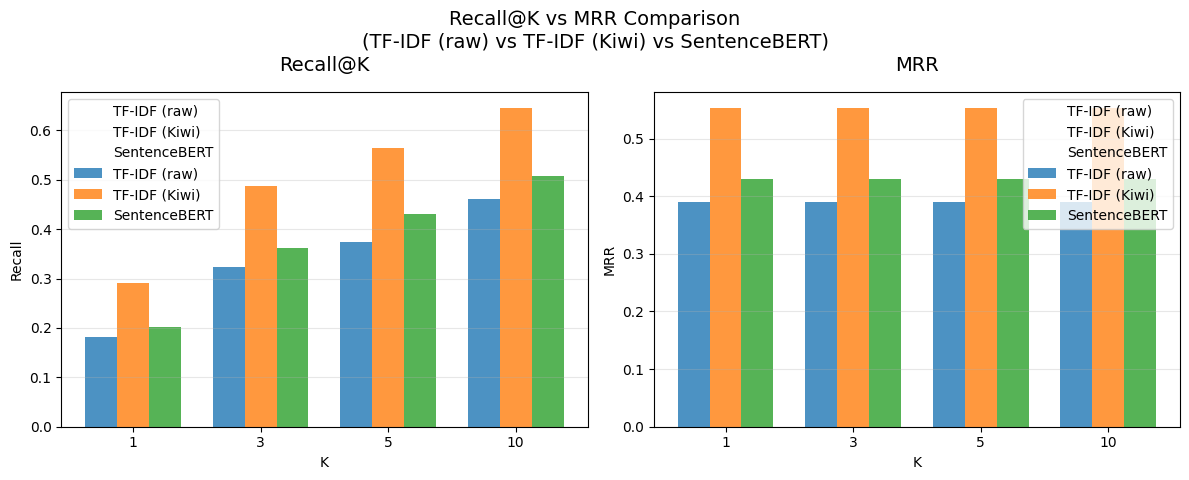

In [42]:
import matplotlib.pyplot as plt

# Recall@K, MRR 피벗 테이블 (앞에서 만든 것 가정)
# df_pivot_rec: Method × K (Recall@K)
# df_pivot_mrr: Method × K (MRR)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 1) Recall@K 막대 그래프 (왼쪽)
ax1.plot([], [], color="black", label="TF-IDF (raw)", lw=0, marker="")  # 빈 라벨만 추가
ax1.plot([], [], color="black", label="TF-IDF (Kiwi)", lw=0, marker="")
ax1.plot([], [], color="black", label="SentenceBERT", lw=0, marker="")

x = df_pivot_rec.columns   # K 값: [1, 3, 5, 10]

width = 0.25
x_pos = [0, 1, 2, 3]  # K=1,3,5,10 위치

ax1.bar(
    [p - width for p in x_pos],
    df_pivot_rec.loc["TF-IDF (raw)"],
    width=width,
    label="TF-IDF (raw)",
    alpha=0.8,
)
ax1.bar(
    [p for p in x_pos],
    df_pivot_rec.loc["TF-IDF (Kiwi)"],
    width=width,
    label="TF-IDF (Kiwi)",
    alpha=0.8,
)
ax1.bar(
    [p + width for p in x_pos],
    df_pivot_rec.loc["SentenceBERT"],
    width=width,
    label="SentenceBERT",
    alpha=0.8,
)

ax1.set_title("Recall@K", fontsize=14, pad=15)
ax1.set_xlabel("K")
ax1.set_ylabel("Recall")
ax1.set_xticks(x_pos)
ax1.set_xticklabels(x)
ax1.legend()
ax1.grid(axis="y", alpha=0.3)

# 2) MRR 막대 그래프 (오른쪽)
ax2.plot([], [], color="black", label="TF-IDF (raw)", lw=0, marker="")  # 빈 라벨
ax2.plot([], [], color="black", label="TF-IDF (Kiwi)", lw=0, marker="")
ax2.plot([], [], color="black", label="SentenceBERT", lw=0, marker="")

ax2.bar(
    [p - width for p in x_pos],
    df_pivot_mrr.loc["TF-IDF (raw)"],
    width=width,
    label="TF-IDF (raw)",
    alpha=0.8,
)
ax2.bar(
    [p for p in x_pos],
    df_pivot_mrr.loc["TF-IDF (Kiwi)"],
    width=width,
    label="TF-IDF (Kiwi)",
    alpha=0.8,
)
ax2.bar(
    [p + width for p in x_pos],
    df_pivot_mrr.loc["SentenceBERT"],
    width=width,
    label="SentenceBERT",
    alpha=0.8,
)

ax2.set_title("MRR", fontsize=14, pad=15)
ax2.set_xlabel("K")
ax2.set_ylabel("MRR")
ax2.set_xticks(x_pos)
ax2.set_xticklabels(x)
ax2.legend()
ax2.grid(axis="y", alpha=0.3)

fig.suptitle("Recall@K vs MRR Comparison\n(TF-IDF (raw) vs TF-IDF (Kiwi) vs SentenceBERT)", fontsize=14, y=0.95)
fig.tight_layout()
plt.show()

X_tfidf shape: (9251, 35399)
X_sbert shape: (9251, 768)


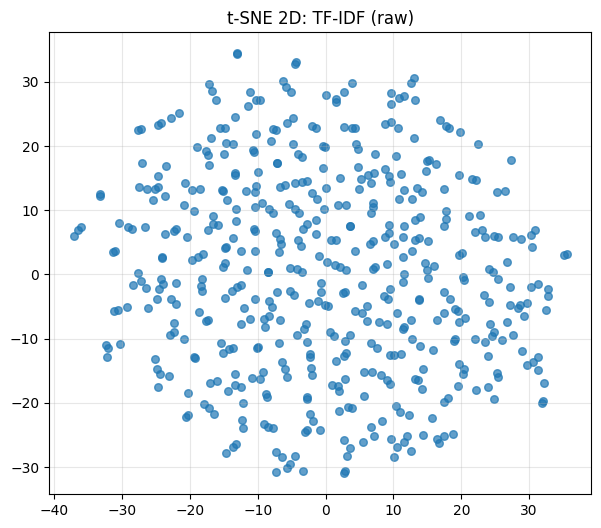

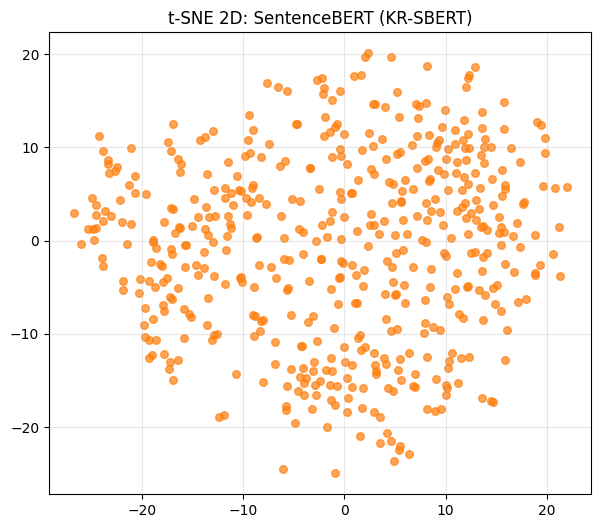

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def tsne_2d_plot(
    emb_list: list[np.ndarray],
    names: list[str],
    n_samples: int = 500,
    title: str = "t-SNE Visualization",
):
    """
    여러 임베딩 리스트를 2D t-SNE로 시각화
    - emb_list: [X1, X2, ...] (각각 [n_samples, dim])
    - names: 각 데이터 이름 ['TF-IDF', 'SentenceBERT', ...]
    """
    colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

    # 1. 각 임베딩에서 500개 정도 샘플링
    sample_inds = []
    sample_embs = []
    for i, emb in enumerate(emb_list):
        n = len(emb)
        idx = np.random.choice(n, size=min(n_samples, n), replace=False)
        sample_inds.append(idx)
        sample_embs.append(emb[idx])

    # 2. concat해서 한 번에 t-SNE 적용
    X_all = np.concatenate(sample_embs, axis=0)
    tsne = TSNE(
        n_components=2,
        perplexity=30,
        n_iter=1000,
        random_state=42,
        init="pca",  # 초기값에 PCA 사용
    )
    X_2d = tsne.fit_transform(X_all)

    # 3. 시각화
    fig, ax = plt.subplots(1, 1, figsize=(10, 7))
    start = 0
    for i, emb in enumerate(sample_embs):
        end = start + len(emb)
        ax.scatter(
            X_2d[start:end, 0],
            X_2d[start:end, 1],
            c=colors[i],
            label=f"{names[i]} (n={len(emb)})",
            alpha=0.7,
            s=20,
        )
        start = end

    ax.set_title(title, fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
import numpy as np

# 1. TF-IDF: tfidf_matrix를 dense numpy로 (원문 기준)
X_tfidf = tfidf_matrix.toarray()  # shape: [n_docs, vocab_size]

# 2. SBERT: 이미 torch.Tensor 또는 numpy.ndarray
if isinstance(corpus_embeddings, np.ndarray):
    X_sbert = corpus_embeddings
else:
    X_sbert = corpus_embeddings.detach().numpy()

print("X_tfidf shape:", X_tfidf.shape)
print("X_sbert shape:", X_sbert.shape)
def plot_single_tsne(X, title, n_samples=500, color="tab:blue"):
    n = len(X)
    idx = np.random.choice(n, size=min(n_samples, n), replace=False)
    emb_small = X[idx]
    X_2d = TSNE(n_components=2, random_state=42).fit_transform(emb_small)
    plt.figure(figsize=(7, 6))
    plt.scatter(X_2d[:, 0], X_2d[:, 1], c=color, alpha=0.7, s=30)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.show()

# TF-IDF만
plot_single_tsne(X_tfidf, "t-SNE 2D: TF-IDF (raw)", n_samples=500, color="tab:blue")

# SBERT만
plot_single_tsne(X_sbert, "t-SNE 2D: SentenceBERT (KR-SBERT)", n_samples=500, color="tab:orange")

In [47]:
from collections import defaultdict

def hybrid_search(
    query,
    qid,
    search_tfidf,           # TF-IDF 검색 함수
    search_sbert,           # SBERT 검색 함수
    qrels,                  # 1개 쿼리에 대한 relevant_docs를 보기 위해
    doc_id_list,            # 문서 id 순서 유지용
    tfidf_vectorizer,       # TF-IDF 준비용 (예시)
    tfidf_matrix,           # TF-IDF 매트릭스
    model,                  # SBERT 모델
    corpus_embeddings,      # SBERT 임베딩
    alpha=0.5,              # 0.0: TF-IDF, 1.0: SBERT
    top_k=10,
):
    # 1. TF-IDF 검색
    tfidf_scores = search_tfidf(
        query, top_k=100,  # 좀 더 넓게 보고 정렬
        use_preprocessing=True,
        doc_id_list=doc_id_list,
        tfidf_vectorizer=tfidf_vectorizer,
        tfidf_matrix=tfidf_matrix,
        tokenize_kiwi=tokenize_kiwi,
    )
    tfidf_rank = {doc_id: rank for rank, (doc_id, _) in enumerate(tfidf_scores, start=1)}

    # 2. SBERT 검색
    sbert_scores = search_sbert(
        query,
        doc_id_list=doc_id_list,
        model=model,
        corpus_embeddings=corpus_embeddings,
        top_k=100,
    )
    sbert_rank = {doc_id: rank for rank, (doc_id, _) in enumerate(sbert_scores, start=1)}

    # 3. 모든 후보 문서를 합치기
    candidate_docs = set(tfidf_rank.keys()) | set(sbert_rank.keys())

    # 4. 하이브리드 점수: 1/rank를 가중 평균
    hybrid_scores = []
    for doc_id in candidate_docs:
        t_score = 1.0 / tfidf_rank.get(doc_id, 999999)  # TF-IDF 순위 역수
        s_score = 1.0 / sbert_rank.get(doc_id, 999999)  # SBERT 순위 역수
        score = (1 - alpha) * t_score + alpha * s_score
        hybrid_scores.append((doc_id, score))

    # 5. 점수로 정렬 후 상위 top_k
    ranked = sorted(hybrid_scores, key=lambda x: x[1], reverse=True)[:top_k]
    return [doc_id for doc_id, _ in ranked]

from collections import defaultdict

recall5_by_alpha = defaultdict(float)
count_by_alpha = defaultdict(int)

for qid, query in queries.items():
    rel_docs = set(qrels.get(qid, []))
    if not rel_docs:
        continue

    for alpha in alphas:
        ranked = hybrid_search(
            query, qid, search_tfidf, search_sbert, qrels,
            doc_id_list, tfidf_vectorizer, tfidf_matrix,
            model, corpus_embeddings, alpha=alpha, top_k=10,
        )
        recall_5 = recall_at_k(ranked, rel_docs, k=5)
        recall5_by_alpha[alpha] += recall_5
        count_by_alpha[alpha] += 1

# 평균 Recall@5
mean_recall5 = {
    alpha: recall5_by_alpha[alpha] / count_by_alpha[alpha]
    for alpha in alphas
}

optimal_alpha = max(mean_recall5, key=mean_recall5.get)
print("Mean Recall@5 by alpha:")
for alpha, rec in mean_recall5.items():
    print(f"  α = {alpha:4.1f} → {rec:.4f}")
print(f"최적 α = {optimal_alpha:.1f}")

Mean Recall@5 by alpha:
  α =  0.0 → 0.5640
  α =  0.1 → 0.5782
  α =  0.2 → 0.5985
  α =  0.3 → 0.6083
  α =  0.4 → 0.6077
  α =  0.5 → 0.6066
  α =  0.6 → 0.5931
  α =  0.7 → 0.5668
  α =  0.8 → 0.5431
  α =  0.9 → 0.4615
  α =  1.0 → 0.4303
최적 α = 0.3
